# SEIHR model

Adding hospitalisation to the SEIR model previously done. I've also separated Infectious into two: Infectious symptomatic ($I^S$) and Infectious asymptomatic ($I^A$). The probability of having symptoms is $d$. It's assumed that only those with symptoms can go to hospital, which happens with probability $h$. For those in hospital, 'removal' (ie recovered or dead) rate is slower, $\delta < \gamma$. 

I've also changed it to be population instead of proportion - so $S+E+I^S +I^A +H+R = N$ for all time points, where $N$ is total population size.

Finally, I've added the possibility of people in the removed category becoming susceptible via the $\omega R$ term in the first equation.

The equations are:
$$\dfrac{dS}{dt} = - \lambda \frac{S}{N} + \omega R$$ 

$$\dfrac{dE}{dt} =  \lambda \frac{S}{N} - \epsilon E$$ 

$$\dfrac{dI^S}{dt} = \epsilon d E - \gamma I^S$$

$$\dfrac{dI^A}{dt} = \epsilon (1-d) E - \gamma I^A$$

$$\dfrac{dH}{dt} = \gamma h I^S - \delta H$$

$$\dfrac{dR}{dt} = \delta H + \gamma (1 - h)I^S + \gamma I^A - \omega R$$

for parameters:

- $\lambda$: the force of infection

- $\epsilon$: the rate of becoming infectious ($\frac{1}{\epsilon}$ is latent period)

- $\gamma$: rate of moving out of 'infectious' category (hospitalised or recovered) ($\frac{1}{\gamma}$ is average infectious period)

- $\delta$: recovery rate of hospitalised patients ($\delta < \gamma$)

- $\omega$: rate that recovered patients become suscptible again

- $d$: probability of having symptoms

- $h$: probability of hospitalisation


The force of infection, $\lambda$, is given by:

$$ \lambda = \beta (\tau I^A + I^S + \rho H)$$

Where $\beta$ is the transmission rate, $\tau$ the infectiousness of asymptomatic patients, and $\rho$ the infectiousness of hospitalised patients.

In [33]:
import scipy.integrate as spi
import numpy as np
import matplotlib.pyplot as plt

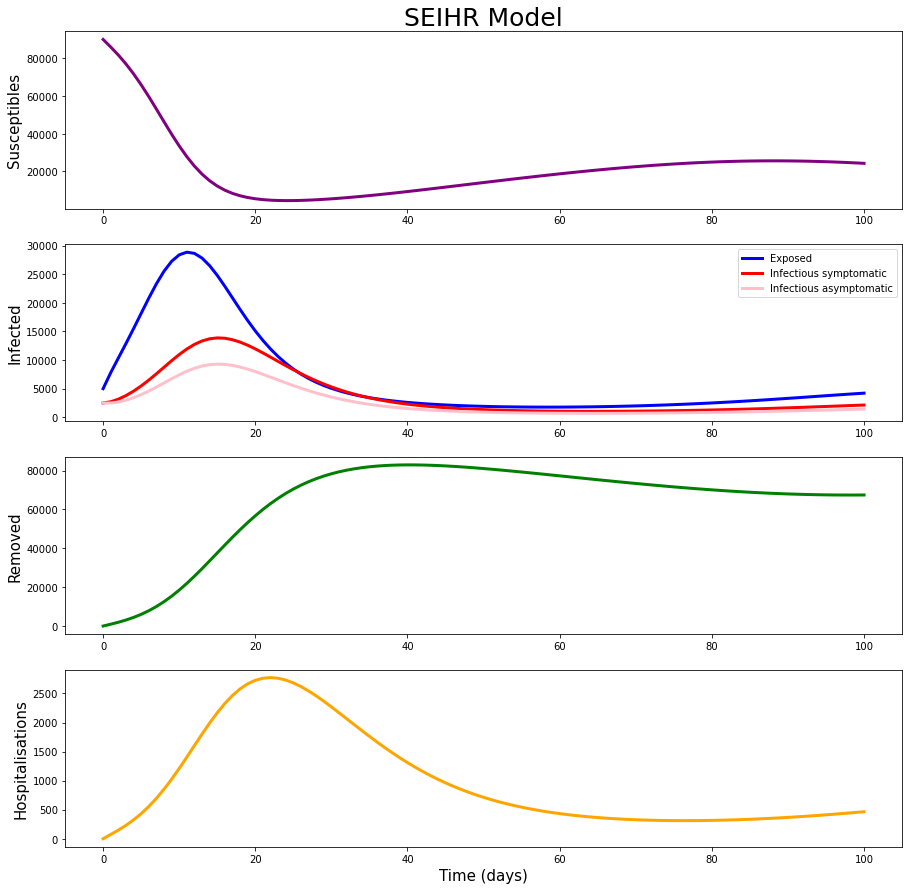

In [56]:
# Rates
beta = 1.4247 
epsilon = 1/5.28
gamma = 1/5 
delta = 1/8.78 
tau = 0.25 
rho = 0.1
omega = 1/100
d = 0.6
h = 0.15 

# Population sizes
N = 100000   #total
S0 = 90000
E0 = 5000
I_S0 = 2500
I_A0 = 2500
H0 = 0
R0=0

# Time values
t_start = 0
days = 100
t_step=1.0


InitialVals = [S0, E0, I_S0, I_A0, H0, R0]

# equations for dS/dt, dE/dt, dI/dt, dH/dt using initial values
def SEIHRmodel(IVS,time):  
    
    FOI = beta*(tau*IVS[3] + IVS[2] + rho*IVS[4]) #force of infection depends on number of infected people
    
    S = - FOI * IVS[0]/N + omega*IVS[5]
    E = FOI * IVS[0]/N - epsilon*IVS[1]
    I_S = epsilon*d*IVS[1] - gamma*IVS[2]
    I_A = epsilon*(1 - d)*IVS[1] - gamma*IVS[3]
    H = gamma*h*IVS[2] - delta*IVS[4]
    R = delta*IVS[4] + gamma*(1 - h)*IVS[2] + gamma*IVS[3] - omega*IVS[5]
    
    Y = [S, E, I_S, I_A, H, R]
    return(Y) 


t = np.arange(t_start, days+t_step, t_step)
values = spi.odeint(SEIHRmodel, InitialVals, t)


# Plotting:
plt.figure(figsize=(15, 15))


plt.subplot(411)
plt.plot(values[:,0], 'purple', linewidth = 3, label='Susceptible')
plt.title('SEIHR Model', fontsize=25)
plt.ylabel('Susceptibles', fontsize=15)

plt.subplot(412)
plt.plot(values[:,1], 'blue', linewidth = 3, label='Exposed')
plt.plot(values[:,2], 'red', linewidth = 3, label = 'Infectious symptomatic')
plt.plot(values[:,3], 'pink', linewidth = 3, label = 'Infectious asymptomatic')
plt.legend(loc=0)
plt.ylabel('Infected', fontsize=15)

plt.subplot(413)
plt.plot(values[:,5], 'green', linewidth = 3, label='Removed')
plt.ylabel('Removed', fontsize=15)

plt.subplot(414)
plt.plot(values[:,4], 'orange', linewidth = 3, label = 'Hospitalised')
plt.xlabel('Time (days)', fontsize=15)
plt.ylabel('Hospitalisations', fontsize=15)

plt.show()